# Week 7 Day 2 – Linear Regression

## Objective

Train a Linear Regression model to predict the next day's stock return.

Topics Covered

- Linear Regression
- TimeSeriesSplit
- RMSE
- MAE
- Actual vs Predicted Plot

Author

Mohit Singh

In [33]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [34]:

data = pd.read_csv("../Day01/ml_dataset.csv")

print(data.columns)

print(data.head())

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume', 'SMA_10', 'SMA_20',
       'RSI', 'MACD', 'Signal', 'Return', 'Lag_1', 'Lag_5', 'Lag_21',
       'Target'],
      dtype='object')
        Price              Close               High                Low  \
0      Ticker        RELIANCE.NS        RELIANCE.NS        RELIANCE.NS   
1        Date                NaN                NaN                NaN   
2  2020-01-31      628.599609375  647.1238564671794  626.6180767993984   
3  2020-02-03  616.9551391601562  623.3896651574961  606.9583015760081   
4  2020-02-04   635.167724609375  637.8840014691701  622.4323157911366   

                Open       Volume      SMA_10      SMA_20        RSI  \
0        RELIANCE.NS  RELIANCE.NS         NaN         NaN        NaN   
1                NaN          NaN         NaN         NaN        NaN   
2  647.0125063572486     34750310  666.229224  674.894650  25.145877   
3  610.0085691432375     30712290  659.690070  672.311942  24.072083   
4   623

## Dataset

The prepared machine learning dataset is loaded successfully.

In [35]:
# Feature columns

features = [

    "SMA_10",
    "SMA_20",
    "RSI",
    "MACD",
    "Signal",
    "Lag_1",
    "Lag_5",
    "Lag_21"

]

X = data[features]

y = data["Target"]

## Feature Matrix

X contains technical indicators.

y contains the next day's return.

In [36]:
# Time-series split

tscv = TimeSeriesSplit(n_splits=5)

In [37]:
# Check missing values

print(X.isnull().sum())

print("\nTarget Missing Values")

print(y.isnull().sum())

SMA_10    2
SMA_20    2
RSI       2
MACD      2
Signal    2
Lag_1     2
Lag_5     2
Lag_21    2
dtype: int64

Target Missing Values
2


In [38]:
# Combine features and target

dataset = pd.concat([X, y], axis=1)

# Remove rows with missing values

dataset = dataset.dropna()

# Separate again

X = dataset[features]

y = dataset["Target"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (1215, 8)
Target Shape : (1215,)


In [39]:
print(X.isnull().sum())

print(y.isnull().sum())

SMA_10    0
SMA_20    0
RSI       0
MACD      0
Signal    0
Lag_1     0
Lag_5     0
Lag_21    0
dtype: int64
0


In [40]:
# Linear Regression model
model = LinearRegression()

for train_index, test_index in tscv.split(X):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

## Model Training

The Linear Regression model is trained using each TimeSeriesSplit fold.
 

In [41]:
# Evaluation metrics

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae = mean_absolute_error(y_test, y_pred)

print("RMSE :", rmse)

print("MAE  :", mae)

RMSE : 0.014082656345978817
MAE  : 0.010285557941296252


In [42]:
with open("regression_metrics.txt", "w") as file:

    file.write(f"RMSE : {rmse}\n")

    file.write(f"MAE  : {mae}\n")

print("Metrics saved successfully.")

Metrics saved successfully.


## Evaluation

RMSE measures the prediction error.

MAE measures the average absolute prediction error.

Lower values indicate better model performance.

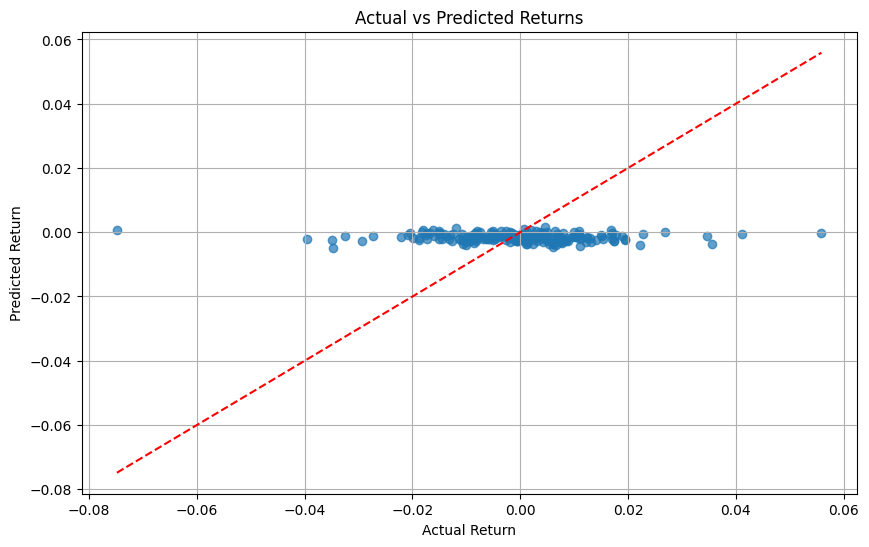

In [43]:
# Plot Actual vs Predicted

plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.xlabel("Actual Return")

plt.ylabel("Predicted Return")

plt.title("Actual vs Predicted Returns")

# Ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.grid(True)

plt.savefig(
    "actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretation

Points close to the red dashed line indicate good predictions.

Points far away indicate larger prediction errors.

In [44]:
coefficients = pd.DataFrame({

    "Feature": features,

    "Coefficient": model.coef_

})

coefficients

,Feature,Coefficient
0,SMA_10,0.000041
1,SMA_20,-0.000047
2,RSI,0.000075
3,MACD,-0.000197
4,Signal,0.000130
5,Lag_1,0.025364
6,Lag_5,-0.049911
7,Lag_21,0.012891


## Feature Importance

Positive coefficient:
The feature tends to increase the predicted return.

Negative coefficient:
The feature tends to decrease the predicted return.

In [45]:
print("Linear Regression completed successfully.")

Linear Regression completed successfully.


# Conclusion

This notebook demonstrates Linear Regression for predicting the next day's stock return.

Completed Tasks

- Loaded prepared dataset
- Built feature matrix
- Used TimeSeriesSplit
- Trained Linear Regression
- Evaluated using RMSE and MAE
- Visualized Actual vs Predicted Returns
- Examined feature coefficients

The dataset and model are now ready for comparison with more advanced machine learning algorithms.